### Import Modules

In [1]:
# Standard Library
import random
from os import environ
from pathlib import Path

# Packages
import mlflow, shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import create_engine

### Constants & Config

In [2]:
# Environment
load_dotenv()

# Paths
ROOT_DIR = Path("../").resolve()

# SQL
ENGINE = create_engine(
    f"postgresql://{environ['POSTGRES_USER']}:{environ['POSTGRES_PASSWORD']}"
    f"@{environ['POSTGRES_HOST']}:{environ['POSTGRES_PORT']}/{environ['FRAUD_DETECTION_DB']}"
)

# Reproducibility
RANDOM_STATE = 42
RNG = np.random.default_rng(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# MLflow
mlflow.set_tracking_uri(f"http://{environ['MLFLOW_HOST']}:{environ['MLFLOW_PORT']}")

### Load Data

In [3]:
data_names = ("test_x", "test_y")
with ENGINE.connect() as connection:
    test_x, test_y = [
        pd.read_sql(f"SELECT * FROM preprocessed_transactions_{name}", connection)
        for name in data_names
    ]

for name, df in dict(zip(data_names, [test_x, test_y])).items():
    print(f"Loaded {len(df):,} rows from {name}")
print(f"\ntest_x  : {test_x.shape}   test_y  : {test_y.shape}")

test_x_np  = test_x.values.astype(np.float32)
test_y_np  = test_y.values.ravel().astype(np.int64)

feature_names = list(test_x.columns)
print(f"\n {feature_names}")

Loaded 56,962 rows from test_x
Loaded 56,962 rows from test_y

test_x  : (56962, 30)   test_y  : (56962, 1)

 ['transaction_timestamp', 'amount', 'v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7', 'v8', 'v9', 'v10', 'v11', 'v12', 'v13', 'v14', 'v15', 'v16', 'v17', 'v18', 'v19', 'v20', 'v21', 'v22', 'v23', 'v24', 'v25', 'v26', 'v27', 'v28']


### Load Model

In [4]:
xgb = mlflow.sklearn.load_model(
    model_uri=f"models:/XGBoost@production"
)

print(xgb.named_steps.keys())
xgb_robust_scaler = xgb.named_steps["robust_scaler"]
xgb_model = xgb.named_steps["xgb"]
xgb_model

dict_keys(['robust_scaler', 'xgb'])


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.939274056922528
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import l

### Load Model Interpreter

In [6]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(test_x_np)

### Global Importance

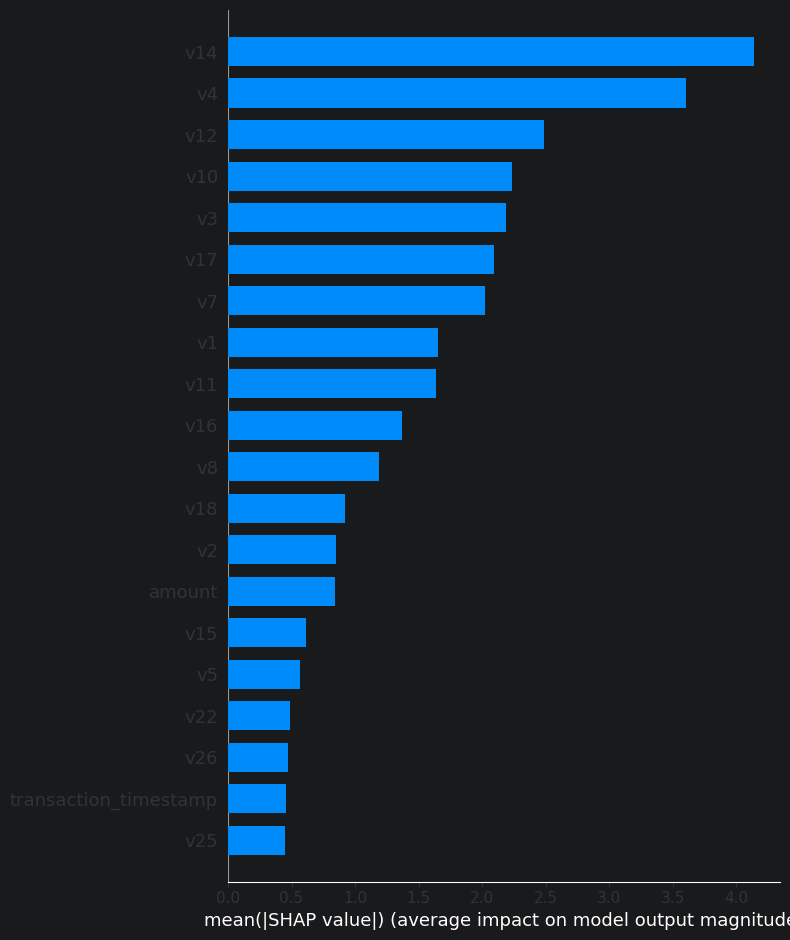

In [7]:
shap.summary_plot(shap_values, test_x_np, plot_type="bar", feature_names=feature_names, rng=RNG)

### Local Interpretation

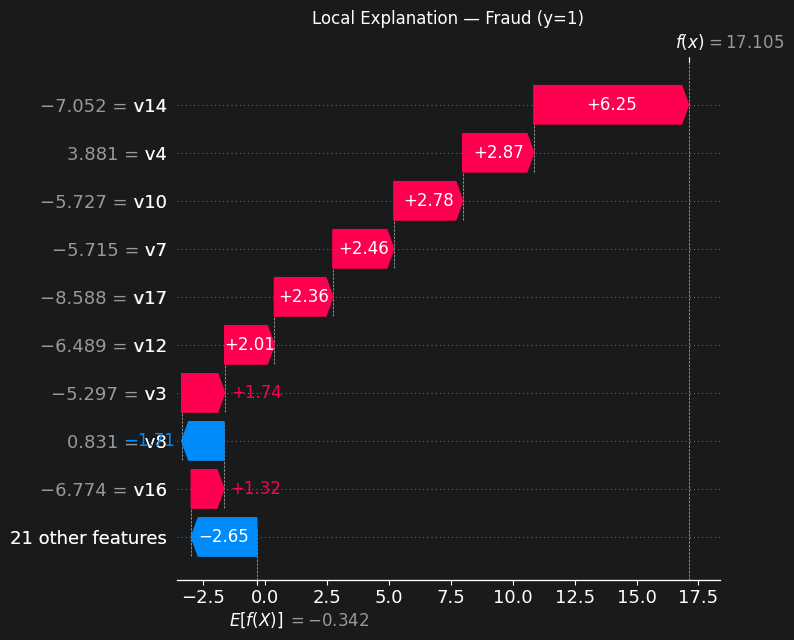

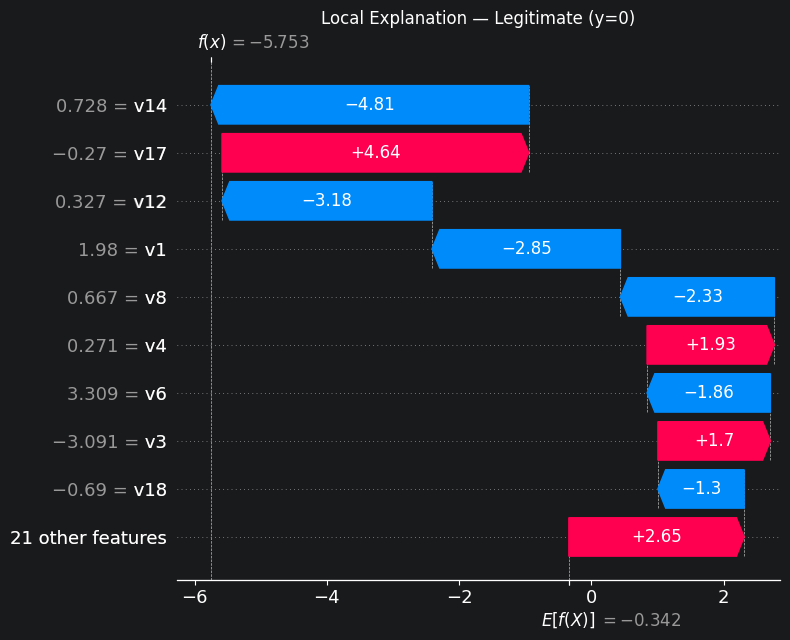

In [8]:
fraud_idx = np.where(test_y_np == 1)[0][0]    # fraud
legit_idx = np.where(test_y_np == 0)[0][0]    # legit

for idx, label in [(int(fraud_idx), "Fraud"), (int(legit_idx), "Legitimate")]:
    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values[idx],
            base_values=explainer.expected_value,
            data=test_x.iloc[idx].to_numpy(),
            feature_names=feature_names
        ),
        show=False
    )
    plt.title(f"Local Explanation — {label} (y={test_y_np[idx]})")
    plt.tight_layout()
    plt.show()